In [9]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150

(640, 480)

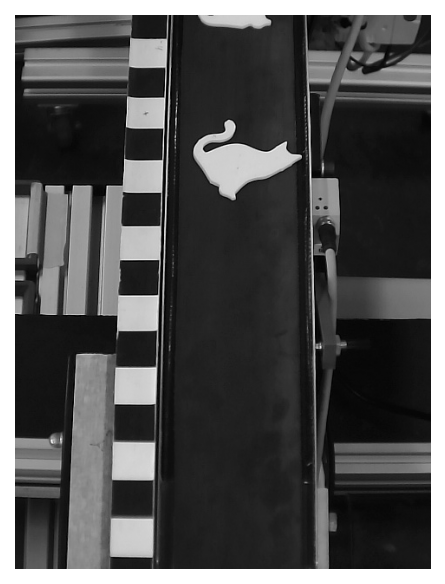

In [10]:
img = cv.imread("bild_49.jpg")
img = cv.rotate(img, 2)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

fig = plt.imshow(img_gray, cmap = 'gray', vmin=0, vmax=255)
plt.axis('off')
img_gray.shape

(640, 195)

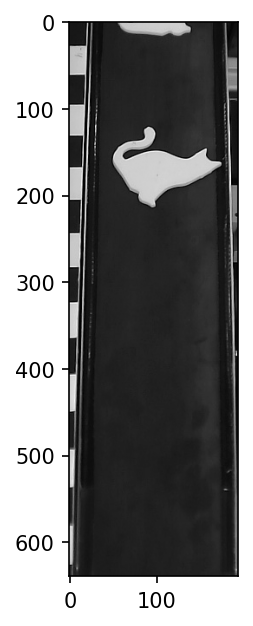

In [11]:
img_gray_focused = img_gray[0:640, 155:350]

fig = plt.imshow(img_gray_focused, cmap = 'gray', vmin=0, vmax=255)
img_gray_focused.shape

/tmp/ipykernel_24407/3416629946.py:1: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img_gray_focused.ravel(), 256, [0,256])


(array([1.950e+02, 7.690e+02, 5.460e+02, 3.670e+02, 2.770e+02, 1.760e+02,
        1.340e+02, 1.290e+02, 1.550e+02, 1.340e+02, 1.500e+02, 1.350e+02,
        2.270e+02, 3.190e+02, 6.400e+02, 9.350e+02, 9.540e+02, 9.130e+02,
        1.034e+03, 1.146e+03, 1.407e+03, 1.745e+03, 1.827e+03, 1.741e+03,
        1.181e+03, 8.660e+02, 8.710e+02, 1.163e+03, 2.059e+03, 3.072e+03,
        3.816e+03, 7.401e+03, 8.196e+03, 8.630e+03, 7.952e+03, 9.364e+03,
        7.842e+03, 5.855e+03, 3.673e+03, 2.953e+03, 2.059e+03, 1.635e+03,
        1.599e+03, 1.408e+03, 1.360e+03, 1.319e+03, 1.191e+03, 1.574e+03,
        2.155e+03, 1.352e+03, 7.850e+02, 5.130e+02, 3.160e+02, 2.450e+02,
        1.350e+02, 1.180e+02, 9.500e+01, 7.500e+01, 8.200e+01, 5.300e+01,
        6.100e+01, 6.400e+01, 6.400e+01, 6.500e+01, 8.100e+01, 7.400e+01,
        6.000e+01, 5.900e+01, 5.400e+01, 6.700e+01, 6.200e+01, 5.800e+01,
        6.600e+01, 6.000e+01, 4.600e+01, 3.400e+01, 4.000e+01, 4.100e+01,
        4.100e+01, 4.600e+01, 4.500e+0

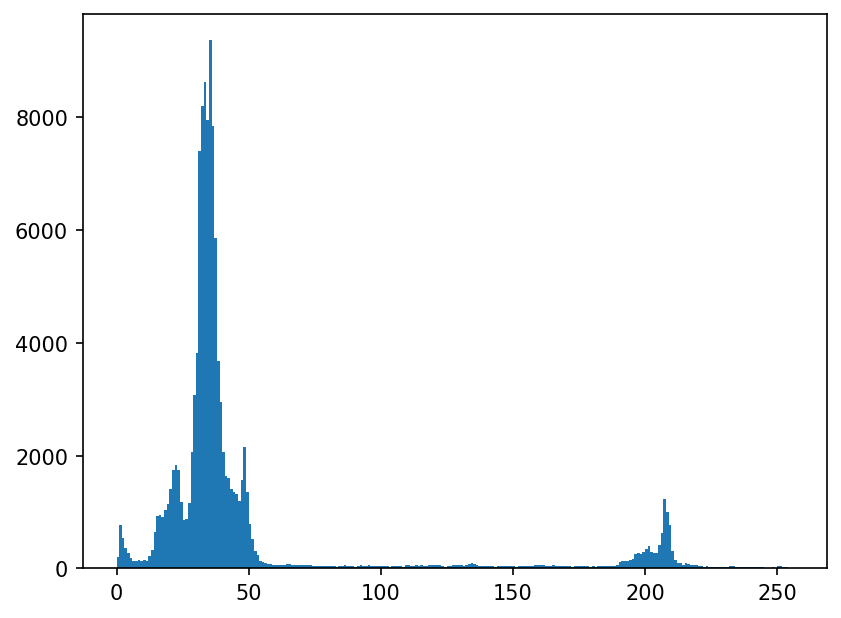

In [12]:
plt.hist(img_gray_focused.ravel(), 256, [0,256])

0.0 255.0


(-0.5, 194.5, 639.5, -0.5)

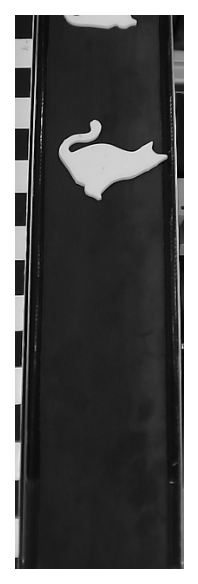

In [13]:
img_spreaded = (img_gray_focused - img_gray_focused.min()) * (255.0 / (img_gray_focused.max() - img_gray_focused.min()))
print(img_spreaded.min(), img_spreaded.max())

fig = plt.imshow(img_spreaded, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

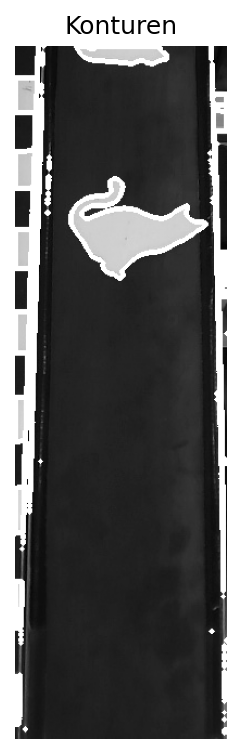

In [14]:
ret , img_thresh = cv.threshold(img_spreaded, 127, 255,cv.THRESH_BINARY)

uint8_img_thresh = img_thresh.astype(np.uint8)

contours , hierarchy = cv.findContours(uint8_img_thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)

img_with_contours = img_spreaded.copy()
cv.drawContours(img_with_contours, contours, contourIdx= -1 , color= (255, 255, 255),thickness=3)

plt.figure(figsize=(8, 6))
plt.imshow(img_with_contours, cmap='gray')
plt.title('Konturen')
plt.axis('off')
plt.show()

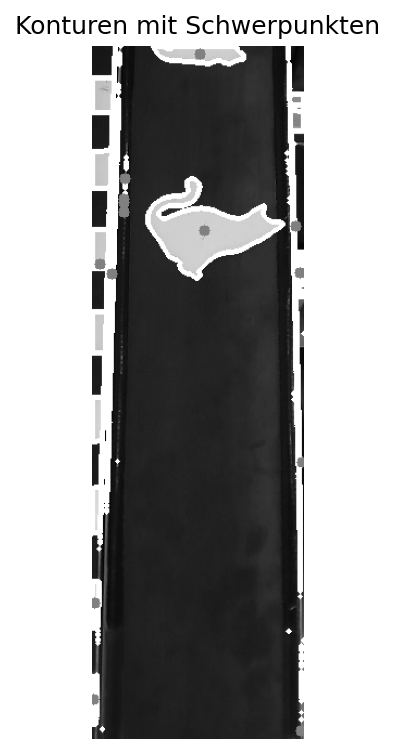

In [15]:
img_with_centroids = img_with_contours.copy()

for contour in contours:
    M = cv.moments(contour)
    
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        
        cv.circle(img_with_centroids, (cx, cy), radius=5, color=(128), thickness=-1)

plt.figure(figsize=(8, 6))
plt.imshow(img_with_centroids, cmap='gray')
plt.title('Konturen mit Schwerpunkten')
plt.axis('off')
plt.show()

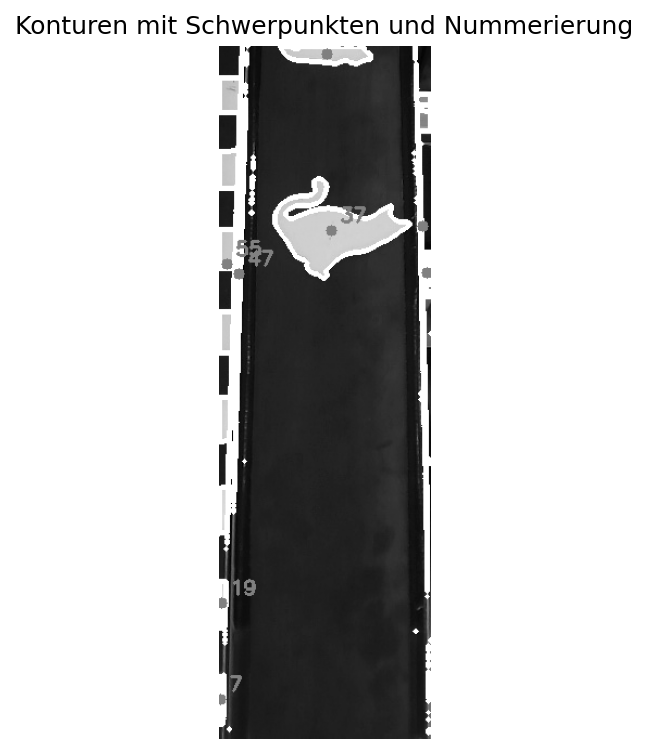

In [16]:
img_with_centroids = img_with_contours.copy()

for i, contour in enumerate(contours):
    if cv.contourArea(contour) < 100:
        continue
    
    M = cv.moments(contour)
    
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        
        cv.circle(img_with_centroids, (cx, cy), radius=5, color=(128), thickness=-1)
        
        cv.putText(
            img_with_centroids,
            text=str(i + 1),
            org=(cx + 8, cy - 8),
            fontFace=cv.FONT_HERSHEY_SIMPLEX,
            fontScale=0.6,
            color=(128),
            thickness=2,
            lineType=cv.LINE_AA
        )

plt.figure(figsize=(8, 6))
plt.imshow(img_with_centroids, cmap='gray')
plt.title('Konturen mit Schwerpunkten und Nummerierung')
plt.axis('off')
plt.show()